In [ ]:
# Mount Google Drive (Colab only)
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
!cp /content/drive/My\ Drive/cats_and_dogs_small.zip /content
!unzip -q cats_and_dogs_small.zip

In [ ]:
train_dir = 'cats_and_dogs_small/train'
validation_dir = 'cats_and_dogs_small/validation'
test_dir = 'cats_and_dogs_small/test'

IMG_WIDTH, IMG_HEIGHT = 150, 150
BATCH_SIZE = 32

In [ ]:
# Build MobileNetV2 transfer learning model
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(weights='imagenet', include_top=False,
                         input_shape=(IMG_WIDTH, IMG_HEIGHT, 3))
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])
model.summary()

In [ ]:
# Visualize architecture
from tensorflow.keras.utils import plot_model
plot_model(model, show_shapes=True, show_layer_names=True)

In [ ]:
# Compile for Phase 1 (frozen base)
model.compile(loss='binary_crossentropy',
              optimizer=optimizers.RMSprop(learning_rate=1e-4),
              metrics=['accuracy'])

In [ ]:
# Data generators with augmentation
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest')
val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir, target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE, class_mode='binary')
validation_generator = val_datagen.flow_from_directory(
    validation_dir, target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE, class_mode='binary')

steps_per_epoch = train_generator.samples // BATCH_SIZE
validation_steps = validation_generator.samples // BATCH_SIZE

In [ ]:
# Phase 1: Train with frozen base
callbacks_p1 = [
    ModelCheckpoint(filepath='cats_and_dogs_mobilenet.h5',
                    monitor='val_loss', verbose=1, save_best_only=True),
    EarlyStopping(monitor='val_loss', patience=5, verbose=1,
                  restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=3),
]

history_p1 = model.fit(
    train_generator, steps_per_epoch=steps_per_epoch, epochs=30,
    validation_data=validation_generator, validation_steps=validation_steps,
    callbacks=callbacks_p1)

In [ ]:
# Phase 2: Fine-tune last 30 layers
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(loss='binary_crossentropy',
              optimizer=optimizers.RMSprop(learning_rate=1e-5),
              metrics=['accuracy'])

callbacks_p2 = [
    ModelCheckpoint(filepath='cats_and_dogs_mobilenet.h5',
                    monitor='val_loss', verbose=1, save_best_only=True),
    EarlyStopping(monitor='val_loss', patience=5, verbose=1,
                  restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=3),
]

history_p2 = model.fit(
    train_generator, steps_per_epoch=steps_per_epoch, epochs=20,
    validation_data=validation_generator, validation_steps=validation_steps,
    callbacks=callbacks_p2)

In [ ]:
# Save final model
model.save('cats_and_dogs_mobilenet.h5')

model_json = model.to_json()
with open('cats_and_dogs_mobilenet.json', "w") as json_file:
    json_file.write(model_json)

In [ ]:
# Evaluate on test set
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    test_dir, target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE, class_mode='binary')
test_loss, test_acc = model.evaluate(test_generator)
print(f'Test loss: {test_loss:.4f}')
print(f'Test acc:  {test_acc:.4f}')

In [ ]:
# Download model files (Colab)
from google.colab import files
files.download("cats_and_dogs_mobilenet.h5")
files.download("cats_and_dogs_mobilenet.json")

In [ ]:
# Plot combined training curves
import matplotlib.pyplot as plt

acc = history_p1.history['accuracy'] + history_p2.history['accuracy']
val_acc = history_p1.history['val_accuracy'] + history_p2.history['val_accuracy']
loss = history_p1.history['loss'] + history_p2.history['loss']
val_loss = history_p1.history['val_loss'] + history_p2.history['val_loss']
epochs = range(1, len(acc) + 1)
phase1_epochs = len(history_p1.history['accuracy'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs, acc, 'bo-', label='Training acc')
ax1.plot(epochs, val_acc, 'b-', label='Validation acc')
ax1.axvline(x=phase1_epochs, color='gray', linestyle='--', label='Fine-tune start')
ax1.set_title('Training and Validation Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()

ax2.plot(epochs, loss, 'ro-', label='Training loss')
ax2.plot(epochs, val_loss, 'r-', label='Validation loss')
ax2.axvline(x=phase1_epochs, color='gray', linestyle='--', label='Fine-tune start')
ax2.set_title('Training and Validation Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()

plt.tight_layout()
plt.show()

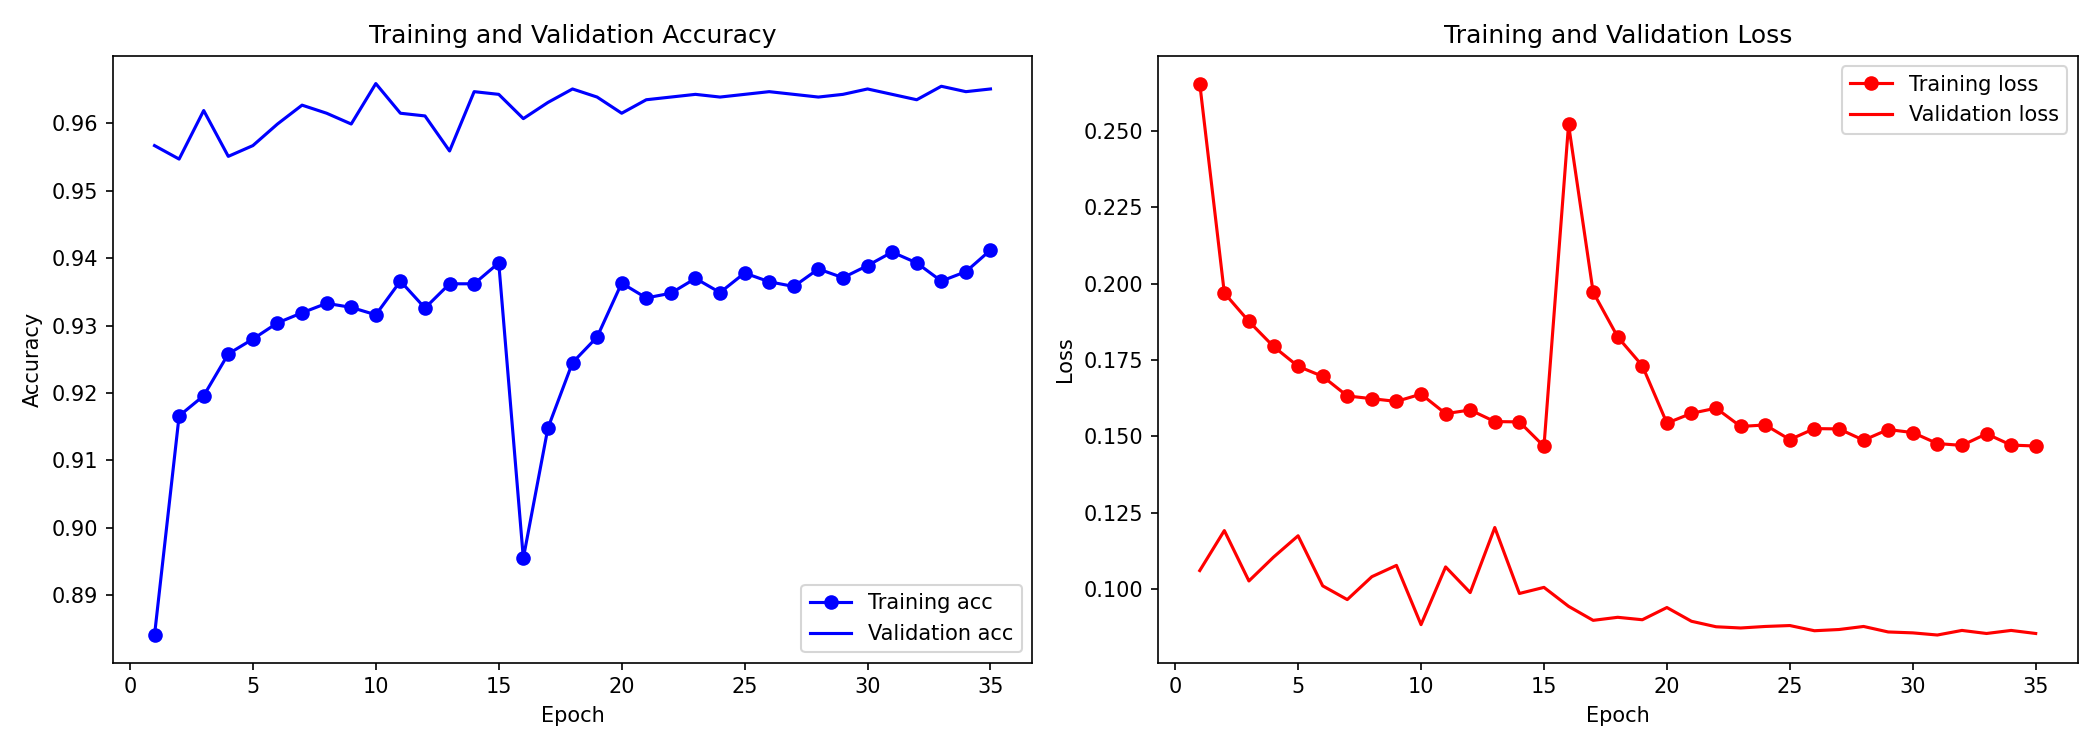

In [1]:
# Display saved training curves (no retraining needed)
from IPython.display import Image, display
display(Image(filename='../model/training_curves.png'))